In [1]:
#Importing the required libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import torchvision.models as models
!pip install optuna
import optuna
import time

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 20.8 MB/s eta 0:00:00


In [2]:
#Mount Google Drive to this notebook
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [3]:
file_path = '/content/drive/MyDrive/Datasets/car_damage_detection/dataset'

In [4]:
#Set the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [5]:
#To Apply transformations to the datasets
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [6]:
#Load the Data to the datasets library
dataset = datasets.ImageFolder(file_path, transform=transform)
print(len(dataset))

2300


In [7]:
#Split the dataset into training and testing ( 80% - Training , 20% - Testing)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
#Number of classes
num_classes = len(dataset.classes)

2


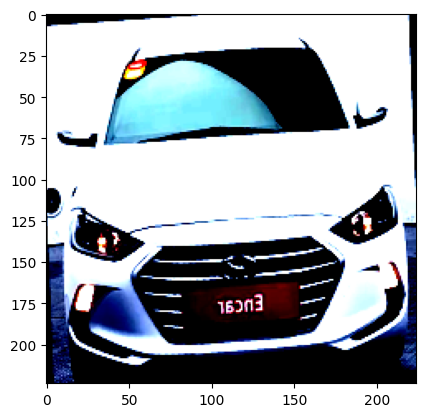

In [8]:
#Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

data_iter = iter(train_loader)
images, labels = next(data_iter)

image = images[2]
image = image.permute(1,2,0)
plt.imshow(image)
print(labels[2].item())

### Training and Validation Loop

In [ ]:
def train_model(model,criterion,optimizer,train_loader,test_loader,epochs):

  train_accuracies = []
  train_losses = []
  test_accuracies = []
  test_losses = []
  for epoch in range(epochs):
    #Training Loop
    model.train()
    running_loss = 0.0
    train_predict = []
    train_true = []
    for image, label in train_loader:
      #Moving image and labels to GPU
      image = image.to(device)
      label = label.to(device)

      #Forward Pass
      output = model(image)
      #Calculate loss
      loss = criterion(output,label)

      #Backward propogation and gradient computation
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      #loss accumulation
      running_loss += loss.item()

      #Store true labels for accuracy prediction during training
      _,predicted = torch.max(output,1)
      train_true.extend(label.cpu().numpy())
      train_predict.extend(predicted.cpu().numpy())

    #Calculate training loss and accuracy
    train_losses.append(running_loss/len(train_loader))
    train_accuracy = accuracy_score(train_true,train_predict)
    train_accuracies.append(train_accuracy)


    #Validation Loop for each epoch
    model.eval()
    val_loss = 0.0
    val_true = []
    val_predicted = []
    with torch.no_grad():
      for image,label in test_loader:
        #Moving image and label to GPU
        image = image.to(device)
        label = label.to(device)

        #Forward pass
        output = model(image)

        #Loss
        loss = criterion(output,label)



        val_loss += loss.item()

        #Storing the predicted values and accuracy for calculation
        _,predicted = torch.max(output,1)
        val_true.extend(label.cpu().numpy())
        val_predicted.extend(predicted.cpu().numpy())

    #Calculate validation loss and accuracy
    test_losses.append(val_loss/len(test_loader))
    val_accuracy = accuracy_score(val_true,val_predicted)
    test_accuracies.append(val_accuracy)

    # Print metrics for the current epoch
    print(f"Epoch {epoch + 1}/{epochs}, "
      f"Train Loss: {train_losses[-1]:.4f}, "
      f"Train Accuracy: {train_accuracy * 100:.2f}%, "
      f"Val Loss: {test_losses[-1]:.4f}, "
      f"Val Accuracy: {val_accuracy * 100:.2f}%")



  return train_losses,train_accuracies,test_losses,test_accuracies

## 1) Model - 1 : Traning the model with CNN

Here’s the explanation formatted for you to paste into a text cell in Google Colab:

---

### **Understanding `self.to_linear = output.view(output.size(0), -1).shape[1]`**

This line dynamically determines the flattened size of the feature maps after passing through the convolutional layers. This is important because the image size reduces after multiple convolutions and pooling operations, and we need to know the exact number of features that will be passed into the fully connected (`Linear`) layers.

---

### **Step-by-Step Breakdown**  
Assume that the output from `self.network` (before flattening) has the shape:
```python
output.shape == (batch_size, num_channels, height, width)
```
where:  
- `batch_size` is the number of images in the batch.  
- `num_channels` is the number of feature maps after the last `Conv2d` layer.  
- `height` and `width` are the spatial dimensions of the feature maps after pooling.

Now, let's analyze the transformation:

#### **1️⃣ `output.view(output.size(0), -1)`**  
```python
output.size(0)  # This is batch_size (e.g., 1 for a single test input)
```
- `.view(output.size(0), -1)` reshapes the tensor so that **all remaining dimensions (channels, height, width) are flattened** into a single vector.  
- `-1` tells PyTorch to infer the appropriate size for this dimension.

**Example:**  
If `output.shape == (1, 64, 7, 7)`, then:
```python
output.view(output.size(0), -1).shape  # Becomes (1, 64 * 7 * 7) → (1, 3136)
```

#### **2️⃣ `.shape[1]` extracts the flattened size**
- `.shape[1]` gets the second dimension (the number of features per sample).  
- In our example:  
  ```python
  output.view(output.size(0), -1).shape[1]  # Returns 3136
  ```
- This gives the correct input size for the first `Linear` layer.

---

### **Final Explanation**
The whole line:
```python
self.to_linear = output.view(output.size(0), -1).shape[1]
```
ensures that the fully connected layer is created with the correct input size, **no matter what image size is used**.  

This avoids hardcoding values and makes the model adaptable to different input dimensions.

---

### **Debugging Tip**
If unsure about the shape at any point, print it:
```python
print(output.shape)  # Before flattening
print(output.view(output.size(0), -1).shape)  # After flattening
```
This helps in understanding how dimensions change dynamically. 🚀

---

This should be ready to paste into your Google Colab text cell! 🚀

In [ ]:
class CarClassifierCNN(nn.Module):
  def __init__(self, num_classes):
    super(CarClassifierCNN,self).__init__()
    #Declare a sequential network
    self.network = nn.Sequential(
        #CNN network - 1
        nn.Conv2d(in_channels=3, out_channels=64, kernel_size=(7,7), padding="same"),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=(2,2),stride=2),

        #CNN network - 2
        nn.Conv2d(in_channels=64, out_channels=128, kernel_size=(3,3), padding="same"),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=(2,2),stride=2),

        #CNN network - 3
        nn.Conv2d(in_channels=128, out_channels=256, kernel_size=(3,3), padding="same"),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=(2,2),stride=2),


        # CNN Block 4 - Reducing Channel Dimension (using 1x1 convolution)
        nn.Conv2d(in_channels=256, out_channels=64, kernel_size=1, padding=0),
        nn.ReLU(),

        #Fully Connected Layer
        nn.Flatten()
    )
    self.linear_size = self.get_flatten_size()

    #Fully Connected Layer
    self.fc = nn.Sequential(
        nn.Linear(self.linear_size, 128),
        nn.ReLU(),
        nn.Linear(128,num_classes)
    )


  def get_flatten_size(self):
    #Helper function to determine the size of the flatten layer
    with torch.no_grad():
      sample_input = torch.randn(1,3,224,224)
      output = self.network(sample_input)
      self.to_linear = output.view(output.size(0), -1).shape[1]
      return self.to_linear

  def forward(self,x):
    x = self.network(x)
    x = self.fc(x)
    return x




In [ ]:
#Initiate the model, loss function and the optimizer
model = CarClassifierCNN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

In [ ]:
 train_losses,train_accuracies,test_losses,test_accuracies = train_model(model,criterion,optimizer,train_loader,test_loader,epochs=5)

Epoch 1/5, Train Loss: 1.5627, Train Accuracy: 37.07%, Val Loss: 1.3216, Val Accuracy: 47.17%
Epoch 2/5, Train Loss: 1.2808, Train Accuracy: 47.34%, Val Loss: 1.2770, Val Accuracy: 49.35%
Epoch 3/5, Train Loss: 1.2162, Train Accuracy: 50.82%, Val Loss: 1.2379, Val Accuracy: 51.30%
Epoch 4/5, Train Loss: 1.1665, Train Accuracy: 51.03%, Val Loss: 1.2235, Val Accuracy: 52.17%
Epoch 5/5, Train Loss: 1.1031, Train Accuracy: 55.71%, Val Loss: 1.1457, Val Accuracy: 51.74%


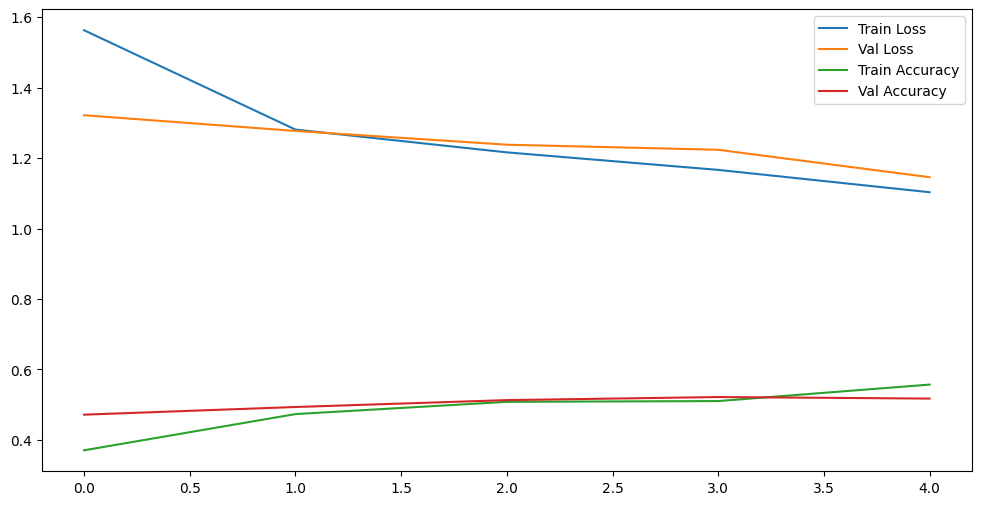

In [ ]:
#Plotting the training and validation losses
plt.figure(figsize=(12, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Val Loss')
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Val Accuracy')
plt.legend()
plt.show()

### 2) Model-2 : CNN with Regularization, Dropout and BatchNormalization

In [ ]:
class CarClassifierCNN_Regularization(nn.Module):
  def __init__(self, num_classes):
    super(CarClassifierCNN_Regularization,self).__init__()
    #Declare a sequential network
    self.network = nn.Sequential(
        #CNN network - 1
        nn.Conv2d(in_channels=3, out_channels=64, kernel_size=(7,7), padding="same"),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=(2,2),stride=2),

        #CNN network - 2
        nn.Conv2d(in_channels=64, out_channels=128, kernel_size=(3,3), padding="same"),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=(2,2),stride=2),

        #CNN network - 3
        nn.Conv2d(in_channels=128, out_channels=256, kernel_size=(3,3), padding="same"),
        nn.BatchNorm2d(256),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=(2,2),stride=2),


        # CNN Block 4 - Reducing Channel Dimension (using 1x1 convolution)
        nn.Conv2d(in_channels=256, out_channels=64, kernel_size=1, padding=0),
        nn.BatchNorm2d(64),
        nn.ReLU(),

        #Fully Connected Layer
        nn.Flatten()
    )
    self.linear_size = self.get_flatten_size()

    #Fully Connected Layer
    self.fc = nn.Sequential(
        nn.Linear(self.linear_size, 128),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(128,num_classes)
    )


  def get_flatten_size(self):
    #Helper function to determine the size of the flatten layer
    with torch.no_grad():
      sample_input = torch.randn(1,3,224,224)
      output = self.network(sample_input)
      self.to_linear = output.view(output.size(0), -1).shape[1]
      return self.to_linear

  def forward(self,x):
    x = self.network(x)
    x = self.fc(x)
    return x

In [ ]:
#Initiate the model, loss function and the optimizer
model = CarClassifierCNN_Regularization(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001,weight_decay=1e-4)

In [ ]:
train_losses,train_accuracies,test_losses,test_accuracies = train_model(model,criterion,optimizer,train_loader,test_loader,epochs=5)

Epoch 1/5, Train Loss: 2.2476, Train Accuracy: 21.96%, Val Loss: 1.5118, Val Accuracy: 29.78%
Epoch 2/5, Train Loss: 1.5567, Train Accuracy: 37.23%, Val Loss: 1.4260, Val Accuracy: 43.04%
Epoch 3/5, Train Loss: 1.4579, Train Accuracy: 41.03%, Val Loss: 1.3091, Val Accuracy: 48.70%
Epoch 4/5, Train Loss: 1.4970, Train Accuracy: 37.93%, Val Loss: 1.2458, Val Accuracy: 46.96%
Epoch 5/5, Train Loss: 1.3909, Train Accuracy: 40.05%, Val Loss: 1.2243, Val Accuracy: 45.87%


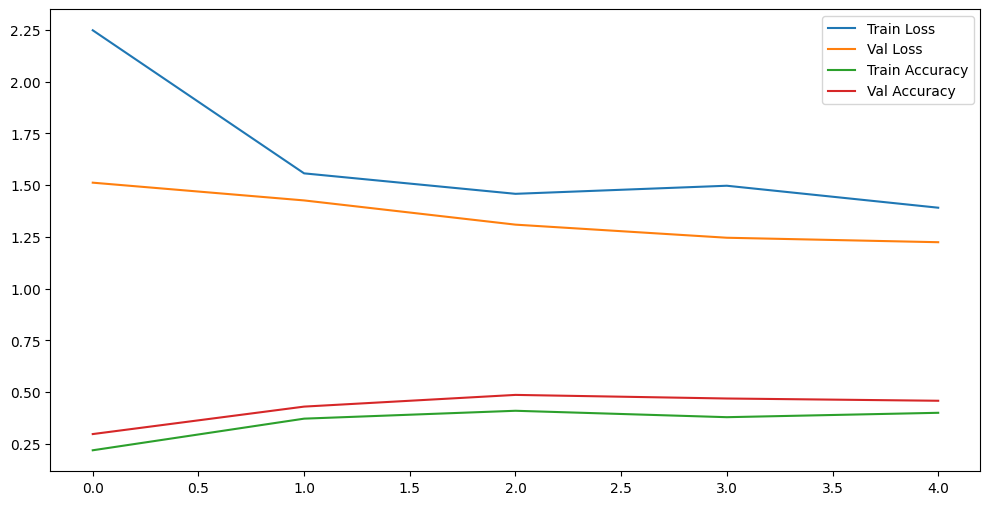

In [ ]:
#Plotting the training and validation losses
plt.figure(figsize=(12, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Val Loss')
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Val Accuracy')
plt.legend()
plt.show()

### 3) Model-3 Transfer Learning implementation using EfficientNet

In [ ]:
#Use EfficientNet Model
class CarClassifierCNN_EfficientNet(nn.Module):
  def __init__(self,num_classes):
    super(CarClassifierCNN_EfficientNet,self).__init__()
    self.model = models.efficientnet_b0(pretrained=True)

    #Freeze all the layers except the FCN
    for param in self.model.parameters():
      param.requires_grad = False

    #Get the input size of the FCN
    in_feature = self.model.classifier[1].in_features

    #Create the classifier
    self.model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_feature, num_classes)
    )

  def forward(self,x):
    return self.model(x)


Here's the formatted explanation that you can paste into a **Jupyter Notebook** text cell:  

---

## **Understanding `filter(lambda p: p.requires_grad, model.parameters())` in Optimizer**  

### **What Does It Do?**  
This ensures that **only trainable parameters** (i.e., parameters with `requires_grad=True`) are passed to the optimizer.  

### **Breaking It Down**  

1. **`model.parameters()`**  
   - Retrieves all model parameters (weights & biases).  
   - Some parameters might be **frozen** (`requires_grad=False`), meaning they should not be updated.  

2. **`lambda p: p.requires_grad`**  
   - A **lambda function** that returns `True` only for parameters where `requires_grad=True`.  
   - It filters out frozen parameters.  

3. **`filter(lambda p: p.requires_grad, model.parameters())`**  
   - `filter()` iterates through `model.parameters()` and **only keeps** parameters where `requires_grad=True`.  
   - This prevents frozen layers from being updated.  

### **Why Is This Useful?**  
In **transfer learning**, we often freeze early layers (feature extractor) and train only the classifier:  

```python
for param in model.features.parameters():
    param.requires_grad = False  # Freeze feature extractor
```
Then, using:  
```python
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
```
ensures **only trainable layers are optimized**.  

### **Alternative Without `filter()`**
Instead of using `filter()`, we can achieve the same result with list comprehension:  

```python
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.Adam(trainable_params, lr=0.001)
```

This is useful when working with **transfer learning** or **fine-tuning** pre-trained models efficiently.

In [ ]:
model = CarClassifierCNN_EfficientNet(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p : p.requires_grad, model.parameters()), lr=0.001)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 66.7MB/s]


In [ ]:
train_losses,train_accuracies,test_losses,test_accuracies = train_model(model,criterion,optimizer,train_loader,test_loader,epochs=5)

Epoch 1/5, Train Loss: 1.4597, Train Accuracy: 42.83%, Val Loss: 1.1860, Val Accuracy: 56.30%
Epoch 2/5, Train Loss: 1.1327, Train Accuracy: 57.83%, Val Loss: 1.0386, Val Accuracy: 60.43%
Epoch 3/5, Train Loss: 1.0182, Train Accuracy: 61.52%, Val Loss: 0.9686, Val Accuracy: 61.52%
Epoch 4/5, Train Loss: 0.9587, Train Accuracy: 62.34%, Val Loss: 0.8965, Val Accuracy: 63.91%
Epoch 5/5, Train Loss: 0.8981, Train Accuracy: 65.43%, Val Loss: 0.8926, Val Accuracy: 63.48%


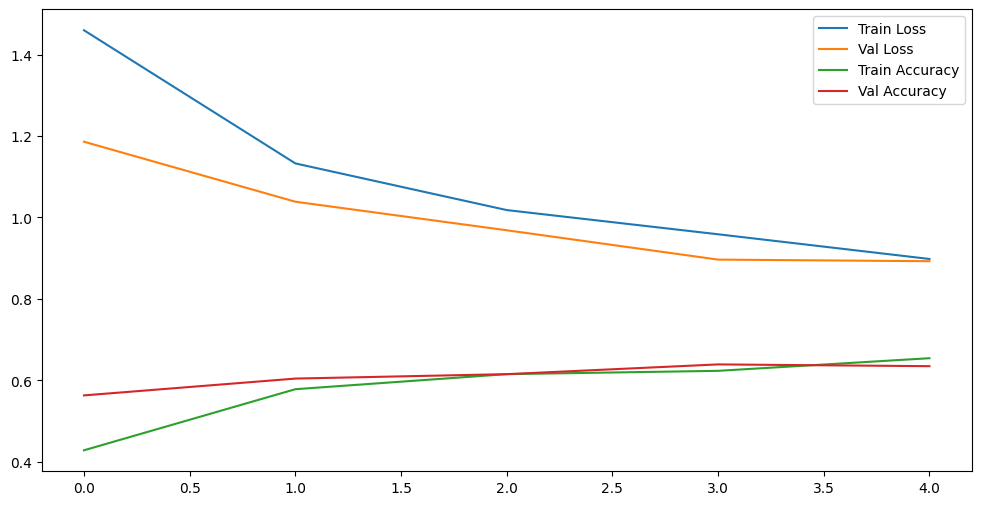

In [ ]:
#Plotting the training and validation losses
plt.figure(figsize=(12, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Val Loss')
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Val Accuracy')
plt.legend()
plt.show()

### 4) Model-4 Transfer Learning implementation using ResNet-50

### **Freezing Layers in ResNet-50 vs. EfficientNet**  

#### **1️⃣ ResNet-50 (Classifier in `model.fc`)**  
```python
# Freeze all layers
for param in model.parameters():
    param.requires_grad = False  

# Unfreeze only the classifier
for param in model.fc.parameters():
    param.requires_grad = True  
```
📌 **Why?** ResNet-50’s classifier is stored in `model.fc`, so we need to explicitly unfreeze it.

---

#### **2️⃣ EfficientNet (Classifier in `model.classifier`)**  
```python
# Freeze feature extractor
for param in model.features.parameters():
    param.requires_grad = False  

# Unfreeze only the classifier
for param in model.classifier.parameters():
    param.requires_grad = True  
```
📌 **Why?** EfficientNet’s classifier is a `Sequential` module inside `model.classifier`.

---

#### **🔹 Why `model.classifier[1].in_features` in EfficientNet?**  
EfficientNet’s classifier has multiple layers, and `model.classifier[1]` is usually the last **fully connected** layer.  
```python
num_ftrs = model.classifier[1].in_features  
model.classifier[1] = nn.Linear(num_ftrs, num_classes)  # Modify last layer
```
✅ **Key Difference:**  
- **ResNet-50 → `model.fc`**  
- **EfficientNet → `model.classifier[1]`**

### **Key Difference: Fine-Tuning vs. Transfer Learning**  

| **Approach**               | **What is Trained?**                          | **When to Use?**  |
|----------------------------|-----------------------------------------------|-------------------|
| **Fine-Tuning (`layer4`)**  | Last convolutional block + classifier         | If dataset is **slightly different** from pretraining  |
| **Transfer Learning (`fc`)** | Only fully connected layer                   | If dataset is **very different**, but pretrained features still help |

#### **1️⃣ Fine-Tuning (Unfreeze `layer4`)**
```python
# Freeze all layers
for param in model.parameters():
    param.requires_grad = False  

# Unfreeze only layer4 (last convolutional block)
for param in model.layer4.parameters():
    param.requires_grad = True
```
✅ **Use case:** If the dataset has **similar features** to the pretraining dataset but requires additional fine-grained learning.

---

#### **2️⃣ Transfer Learning (Train Only Classifier)**
```python
# Freeze entire model
for param in model.parameters():
    param.requires_grad = False  

# Unfreeze only fully connected layer
for param in model.fc.parameters():
    param.requires_grad = True
```
✅ **Use case:** If the dataset is **very different** (e.g., switching from ImageNet to medical images), but pretrained feature extraction is still useful.

🚀 **Tip:** Fine-tuning is **slower but more effective**, while transfer learning is **faster and simpler**.

In [9]:
class CarClassifierCNN_ResNet(nn.Module):
  def __init__(self,num_classes,dropout_rate=0.5):
    super().__init__()
    self.model = models.resnet50(pretrained=True)

    #Freeze all layers except the FCN
    for param in self.model.parameters():
      param.requires_grad = False

    for param in self.model.layer4.parameters():
      param.requires_grad = True

    #Replace the final fully connected layer
    self.model.fc = nn.Sequential(
        nn.Dropout(dropout_rate),
        nn.Linear(self.model.fc.in_features, num_classes)
    )

  def forward(self,x):
    return self.model(x)

In [ ]:
model = CarClassifierCNN_ResNet(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p : p.requires_grad, model.parameters()), lr=0.001)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 159MB/s]


In [ ]:
train_losses,train_accuracies,test_losses,test_accuracies = train_model(model,criterion,optimizer,train_loader,test_loader,epochs=10)

Epoch 1/10, Train Loss: 0.9005, Train Accuracy: 63.21%, Val Loss: 0.8228, Val Accuracy: 68.70%
Epoch 2/10, Train Loss: 0.5962, Train Accuracy: 75.43%, Val Loss: 0.5960, Val Accuracy: 73.04%
Epoch 3/10, Train Loss: 0.4497, Train Accuracy: 82.93%, Val Loss: 1.2497, Val Accuracy: 64.57%
Epoch 4/10, Train Loss: 0.3763, Train Accuracy: 85.38%, Val Loss: 0.5494, Val Accuracy: 78.04%
Epoch 5/10, Train Loss: 0.2907, Train Accuracy: 89.73%, Val Loss: 0.7277, Val Accuracy: 75.87%
Epoch 6/10, Train Loss: 0.2644, Train Accuracy: 90.43%, Val Loss: 0.7838, Val Accuracy: 77.83%
Epoch 7/10, Train Loss: 0.2382, Train Accuracy: 91.63%, Val Loss: 0.8515, Val Accuracy: 75.87%
Epoch 8/10, Train Loss: 0.2163, Train Accuracy: 92.66%, Val Loss: 0.6075, Val Accuracy: 79.13%
Epoch 9/10, Train Loss: 0.1536, Train Accuracy: 94.46%, Val Loss: 0.5516, Val Accuracy: 78.91%
Epoch 10/10, Train Loss: 0.1388, Train Accuracy: 94.78%, Val Loss: 0.8499, Val Accuracy: 76.96%


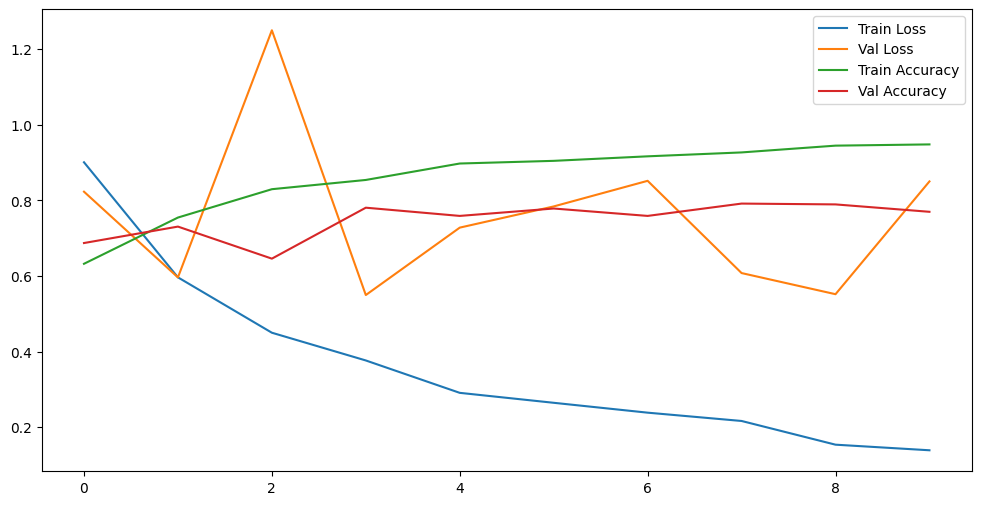

In [ ]:
#Plotting the training and validation losses
plt.figure(figsize=(12, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Val Loss')
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Val Accuracy')
plt.legend()
plt.show()

### 5) Model training using optuna and hyperparamter tuning with ResNet-50

Here’s the explanation of **pruning in Optuna** formatted in **Markdown** for easy storage in a text cell:

---

# **Pruning in Optuna**

## **What is Pruning?**
Pruning is a technique used in **Optuna** to stop underperforming trials early during the hyperparameter optimization process. This helps save computational resources (time, memory, etc.) by avoiding the completion of trials that are unlikely to yield good results.

---

## **How Pruning Works**
1. **Intermediate Results**:
   - During a trial, intermediate results (e.g., validation accuracy after each epoch) are reported using `trial.report(metric, step)`.
   - Optuna uses these intermediate results to decide whether to continue or stop the trial.

2. **Pruning Decision**:
   - Optuna compares the intermediate results of the current trial with the results of previous trials.
   - If the current trial is significantly underperforming, Optuna will **prune** (stop) the trial early.

3. **Pruning Condition**:
   - The condition for pruning is checked using `trial.should_prune()`.
   - If this condition is met, the trial is stopped by raising an `optuna.exceptions.TrialPruned` exception.

---

## **Why Pruning is Useful**
1. **Efficiency**:
   - Pruning avoids wasting time on poorly performing hyperparameter configurations and focuses on more promising ones.
2. **Resource Savings**:
   - By stopping underperforming trials early, computational resources (e.g., GPU/CPU time, memory) are saved.
3. **Faster Optimization**:
   - Pruning speeds up the hyperparameter tuning process by reducing the number of unnecessary iterations.

---

## **Pruning in the Provided Code**
In the code, pruning is implemented as follows:

```python
# Report intermediate result to Optuna
trial.report(accuracy, epoch)

# Handle pruning (if applicable)
if trial.should_prune():
    raise optuna.exceptions.TrialPruned()
```

### **Explanation**
1. **Reporting Intermediate Results**:
   - After each epoch, the validation accuracy (`accuracy`) is reported to Optuna using `trial.report(accuracy, epoch)`.
   - This allows Optuna to track the performance of the trial over time.

2. **Checking for Pruning**:
   - After reporting the intermediate result, the code checks if the trial should be pruned using `trial.should_prune()`.
   - If the trial is underperforming, `trial.should_prune()` returns `True`, and the trial is stopped by raising `optuna.exceptions.TrialPruned`.

3. **Stopping the Trial**:
   - When `TrialPruned` is raised, the trial is terminated early, and Optuna moves on to the next set of hyperparameters.

---

## **Example Scenario**
Suppose you are running 50 trials to optimize hyperparameters for a model. During one trial:
- After the first epoch, the validation accuracy is very low compared to other trials.
- Optuna detects this and decides to prune the trial early.
- Instead of running all 3 epochs, the trial is stopped after the first epoch, saving time and resources.

---

## **Pruning Algorithms in Optuna**
Optuna supports several pruning algorithms, such as:
1. **Median Pruner**:
   - Prunes a trial if its intermediate result is worse than the median of previous trials at the same step.
2. **Percentile Pruner**:
   - Prunes a trial if its intermediate result is in the bottom percentile of previous trials.
3. **Successive Halving Pruner**:
   - Allocates more resources to promising trials and prunes underperforming ones early.

By default, Optuna uses the **Median Pruner**, but you can customize the pruning algorithm when creating the study:

```python
study = optuna.create_study(
    direction='maximize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=2)
)
```

---

## **Key Takeaways**
- Pruning is a mechanism to stop underperforming trials early.
- It improves the efficiency of hyperparameter tuning by saving time and resources.
- In the provided code, pruning is applied after each epoch based on the validation accuracy.

---

Let me know if you need further clarification!

In [ ]:
#Define the objective function for optuna
def objective(trial):
  #Value ranges for the hyperparamters
  lr = trial.suggest_float('lr', 1e-5, 1e-1, log=True)
  dropout_rate = trial.suggest_float('dropout_rate',0.2,0.7)

  #Load the model
  model = CarClassifierCNN_ResNet(num_classes,dropout_rate=dropout_rate).to(device)
  #Define the Loss funciton and the optimizer
  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(filter(lambda p : p.requires_grad, model.parameters()), lr=lr)


  #Train the Loop ( Using fewer epochs for faster hyperparameter tuniung)
  epochs = 3
  start = time.time()
  for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images,labels in train_loader:
      images = images.to(device)
      labels = labels.to(device)

      output = model(images)
      loss = criterion(output, labels)

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      running_loss += loss.item()

    epoch_loss = running_loss/len(train_loader)


    #Validation Loop
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
      for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _,predicted = torch.max(outputs.data,1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct/total


    #Reporting the intermediate results to optuna
    trial.report(accuracy, epoch)

    #Handling pruning (if applicable)
    if trial.should_prune():
      raise optuna.exceptions.TrialPruned()

  end = time.time()
  print(f"Exection time : {end - start} seconds")

  return accuracy


In [ ]:
#Create the study and optimize
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

[I 2025-04-07 15:28:10,899] A new study created in memory with name: no-name-72adea52-2667-4de0-b1fa-76dd45fbe41a
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 202MB/s]
[I 2025-04-07 16:01:35,323] Trial 0 finished with value: 70.65217391304348 and

Exection time : 2003.1077845096588 seconds


[I 2025-04-07 16:05:29,885] Trial 1 finished with value: 78.91304347826087 and parameters: {'lr': 0.00011846373096675622, 'dropout_rate': 0.3468051723646869}. Best is trial 1 with value: 78.91304347826087.


Exection time : 234.0664451122284 seconds


[I 2025-04-07 16:09:25,197] Trial 2 finished with value: 78.26086956521739 and parameters: {'lr': 0.00015388076123315462, 'dropout_rate': 0.2518543363120431}. Best is trial 1 with value: 78.91304347826087.


...

[I 2025-04-07 16:17:16,791] Trial 4 finished with value: 78.26086956521739 and parameters: {'lr': 0.0013177856320031624, 'dropout_rate': 0.6001999690925898}. Best is trial 1 with value: 78.91304347826087.


Exection time : 236.08317351341248 seconds


[I 2025-04-07 16:21:13,667] Trial 5 finished with value: 81.08695652173913 and parameters: {'lr': 0.0003012638590940833, 'dropout_rate': 0.2756654340503414}. Best is trial 5 with value: 81.08695652173913.


Exection time : 236.38753962516785 seconds


[I 2025-04-07 16:22:32,607] Trial 6 pruned. 
[I 2025-04-07 16:23:51,365] Trial 7 pruned. 
[I 2025-04-07 16:25:09,799] Trial 8 pruned. 
[I 2025-04-07 16:29:11,142] Trial 9 pruned. 
[I 2025-04-07 16:30:30,009] Trial 10 pruned. 
[I 2025-04-07 16:34:26,060] Trial 11 pruned. 
[I 2025-04-07 16:35:44,999] Trial 12 pruned. 
[I 2025-04-07 16:38:21,465] Trial 13 pruned. 
[I 2025-04-07 16:40:58,300] Trial 14 pruned. 
[I 2025-04-07 16:44:52,548] Trial 15 pruned. 
[I 2025-04-07 16:48:51,771] Trial 16 pruned. 
[I 2025-04-07 16:51:45,874] Trial 17 pruned. 
[I 2025-04-07 16:53:10,629] Trial 18 pruned. 
[I 2025-04-07 16:55:55,036] Trial 19 pruned. 


In [ ]:
study.best_params

{'lr': 0.0003012638590940833, 'dropout_rate': 0.2756654340503414}

### 6) Rerunning Resnet-50 with the required hyper-parameters for efficient performance 'lr': 0.0003012638590940833, 'dropout_rate': 0.2756654340503414

In [10]:
def train_model_resnet50(model,criterion,optimizer,train_loader,test_loader,epochs):

  train_accuracies = []
  train_losses = []
  test_accuracies = []
  test_losses = []
  for epoch in range(epochs):
    #Training Loop
    model.train()
    running_loss = 0.0
    train_predict = []
    train_true = []
    for image, label in train_loader:
      #Moving image and labels to GPU
      image = image.to(device)
      label = label.to(device)

      #Forward Pass
      output = model(image)
      #Calculate loss
      loss = criterion(output,label)

      #Backward propogation and gradient computation
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      #loss accumulation
      running_loss += loss.item()

      #Store true labels for accuracy prediction during training
      _,predicted = torch.max(output,1)
      train_true.extend(label.cpu().numpy())
      train_predict.extend(predicted.cpu().numpy())

    #Calculate training loss and accuracy
    train_losses.append(running_loss/len(train_loader))
    train_accuracy = accuracy_score(train_true,train_predict)
    train_accuracies.append(train_accuracy)


    #Validation Loop for each epoch
    model.eval()
    val_loss = 0.0
    val_true = []
    val_predicted = []
    with torch.no_grad():
      for image,label in test_loader:
        #Moving image and label to GPU
        image = image.to(device)
        label = label.to(device)

        #Forward pass
        output = model(image)

        #Loss
        loss = criterion(output,label)



        val_loss += loss.item()

        #Storing the predicted values and accuracy for calculation
        _,predicted = torch.max(output,1)
        val_true.extend(label.cpu().numpy())
        val_predicted.extend(predicted.cpu().numpy())

    #Calculate validation loss and accuracy
    test_losses.append(val_loss/len(test_loader))
    val_accuracy = accuracy_score(val_true,val_predicted)
    test_accuracies.append(val_accuracy)

    # Print metrics for the current epoch
    print(f"Epoch {epoch + 1}/{epochs}, "
      f"Train Loss: {train_losses[-1]:.4f}, "
      f"Train Accuracy: {train_accuracy * 100:.2f}%, "
      f"Val Loss: {test_losses[-1]:.4f}, "
      f"Val Accuracy: {val_accuracy * 100:.2f}%")



  return train_losses,train_accuracies,test_losses,test_accuracies,val_true,val_predicted

In [11]:
drop_rate = 0.27566
learning_rate = 0.00030126

model = CarClassifierCNN_ResNet(num_classes,dropout_rate=drop_rate).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p : p.requires_grad, model.parameters()), lr=learning_rate)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 129MB/s]


In [12]:
train_losses,train_accuracies,test_losses,test_accuracies,labels,predictions = train_model_resnet50(model,criterion,optimizer,train_loader,test_loader,epochs=10)

Epoch 1/10, Train Loss: 0.8107, Train Accuracy: 66.41%, Val Loss: 0.6012, Val Accuracy: 76.96%
Epoch 2/10, Train Loss: 0.4850, Train Accuracy: 80.60%, Val Loss: 0.6587, Val Accuracy: 74.13%
Epoch 3/10, Train Loss: 0.3552, Train Accuracy: 87.50%, Val Loss: 0.6189, Val Accuracy: 76.52%
Epoch 4/10, Train Loss: 0.3015, Train Accuracy: 88.97%, Val Loss: 0.8982, Val Accuracy: 72.39%
Epoch 5/10, Train Loss: 0.2094, Train Accuracy: 92.88%, Val Loss: 0.7089, Val Accuracy: 78.48%
Epoch 6/10, Train Loss: 0.1657, Train Accuracy: 94.67%, Val Loss: 0.7733, Val Accuracy: 77.39%
Epoch 7/10, Train Loss: 0.1770, Train Accuracy: 94.13%, Val Loss: 0.7648, Val Accuracy: 76.30%
Epoch 8/10, Train Loss: 0.1263, Train Accuracy: 95.82%, Val Loss: 0.6813, Val Accuracy: 77.83%
Epoch 9/10, Train Loss: 0.1052, Train Accuracy: 96.47%, Val Loss: 0.8555, Val Accuracy: 77.17%
Epoch 10/10, Train Loss: 0.0743, Train Accuracy: 97.66%, Val Loss: 0.7483, Val Accuracy: 79.13%


### Get the accuracy using Classification report and Confusion matrix

In [14]:
report = classification_report(labels, predictions)
print(report)

              precision    recall  f1-score   support

           0       0.87      0.89      0.88        94
           1       0.86      0.67      0.75        82
           2       0.83      0.95      0.89       110
           3       0.74      0.73      0.74        59
           4       0.53      0.58      0.56        55
           5       0.82      0.75      0.78        60

    accuracy                           0.79       460
   macro avg       0.78      0.76      0.77       460
weighted avg       0.80      0.79      0.79       460



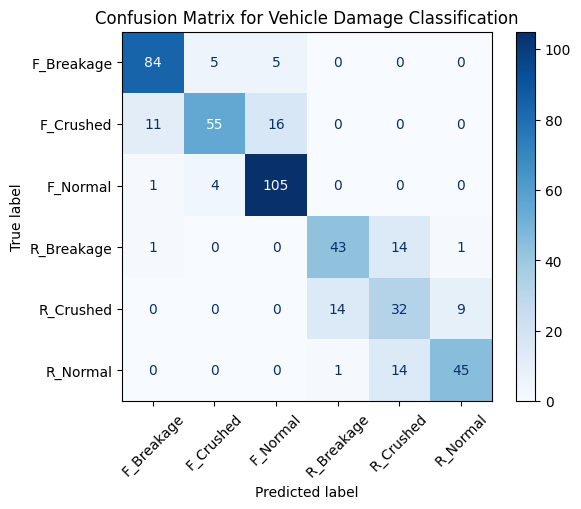

In [18]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt

conf_matrix = confusion_matrix(labels, predictions, labels=np.arange(num_classes))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=dataset.classes)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix for Vehicle Damage Classification")
plt.show()

In [20]:
#Save the Model
torch.save(model.state_dict(), '/content/drive/MyDrive/model.pth')